In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/refs/heads/master/credit-default.csv")
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   checking_balance      1000 non-null   str  
 1   months_loan_duration  1000 non-null   int64
 2   credit_history        1000 non-null   str  
 3   purpose               1000 non-null   str  
 4   amount                1000 non-null   int64
 5   savings_balance       1000 non-null   str  
 6   employment_length     1000 non-null   str  
 7   installment_rate      1000 non-null   int64
 8   personal_status       1000 non-null   str  
 9   other_debtors         1000 non-null   str  
 10  residence_history     1000 non-null   int64
 11  property              1000 non-null   str  
 12  age                   1000 non-null   int64
 13  installment_plan      1000 non-null   str  
 14  housing               1000 non-null   str  
 15  existing_credits      1000 non-null   int64
 16  default           

In [4]:
target = 'default'
X = df.drop(columns=[target])
y = df[target]

In [5]:
X

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,4,real estate,67,none,own,2,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,2,real estate,22,none,own,1,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,3,real estate,49,none,own,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,4,building society savings,45,none,for free,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,4,unknown/none,53,none,for free,2,2,none,yes,skilled employee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,unknown,12,repaid,furniture,1736,< 100 DM,4 - 7 yrs,3,female,none,4,real estate,31,none,own,1,1,none,yes,unskilled resident
996,< 0 DM,30,repaid,car (used),3857,< 100 DM,1 - 4 yrs,4,divorced male,none,4,building society savings,40,none,own,1,1,yes,yes,mangement self-employed
997,unknown,12,repaid,radio/tv,804,< 100 DM,> 7 yrs,4,single male,none,4,other,38,none,own,1,1,none,yes,skilled employee
998,< 0 DM,45,repaid,radio/tv,1845,< 100 DM,1 - 4 yrs,4,single male,none,4,unknown/none,23,none,for free,1,1,yes,yes,skilled employee


In [6]:
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: default, Length: 1000, dtype: int64

In [8]:
y.value_counts() # 1: customer paid back the load, 2: customer defaulted

default
1    700
2    300
Name: count, dtype: int64

In [9]:
# label encoding

In [10]:
from sklearn import preprocessing

In [11]:
label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [12]:
X

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,residence_history,property,age,installment_plan,housing,existing_credits,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,4,real estate,67,none,own,2,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,2,real estate,22,none,own,1,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,3,real estate,49,none,own,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,4,building society savings,45,none,for free,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,4,unknown/none,53,none,for free,2,2,none,yes,skilled employee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,unknown,12,repaid,furniture,1736,< 100 DM,4 - 7 yrs,3,female,none,4,real estate,31,none,own,1,1,none,yes,unskilled resident
996,< 0 DM,30,repaid,car (used),3857,< 100 DM,1 - 4 yrs,4,divorced male,none,4,building society savings,40,none,own,1,1,yes,yes,mangement self-employed
997,unknown,12,repaid,radio/tv,804,< 100 DM,> 7 yrs,4,single male,none,4,other,38,none,own,1,1,none,yes,skilled employee
998,< 0 DM,45,repaid,radio/tv,1845,< 100 DM,1 - 4 yrs,4,single male,none,4,unknown/none,23,none,for free,1,1,yes,yes,skilled employee


In [13]:
label_encoder.inverse_transform(y)

array([1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2,
       1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2,
       1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1,
       2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1,

In [14]:
df.purpose

0        radio/tv
1        radio/tv
2       education
3       furniture
4       car (new)
          ...    
995     furniture
996    car (used)
997      radio/tv
998      radio/tv
999    car (used)
Name: purpose, Length: 1000, dtype: str

In [17]:
le = preprocessing.LabelEncoder()
a= le.fit_transform(df.purpose)
a

array([7, 7, 4, 5, 1, 4, 5, 2, 7, 1, 1, 0, 7, 1, 1, 7, 7, 0, 2, 7, 1, 7,
       1, 2, 5, 5, 7, 7, 7, 0, 0, 5, 1, 0, 5, 7, 4, 7, 3, 7, 7, 7, 8, 2,
       2, 1, 7, 2, 1, 7, 5, 2, 7, 2, 1, 1, 7, 7, 1, 5, 0, 7, 0, 0, 7, 8,
       7, 1, 4, 7, 2, 7, 6, 0, 4, 2, 7, 7, 2, 5, 7, 7, 0, 6, 7, 0, 5, 4,
       1, 8, 7, 2, 7, 5, 1, 0, 4, 0, 7, 2, 1, 7, 7, 5, 2, 6, 1, 1, 5, 0,
       0, 4, 1, 1, 7, 7, 7, 5, 5, 1, 7, 2, 5, 1, 5, 1, 7, 8, 2, 1, 1, 4,
       5, 5, 7, 7, 2, 7, 7, 7, 1, 7, 7, 5, 5, 0, 1, 1, 5, 7, 7, 7, 7, 2,
       0, 5, 8, 9, 1, 7, 7, 1, 3, 1, 1, 5, 5, 5, 5, 0, 1, 5, 5, 7, 4, 2,
       5, 7, 7, 1, 0, 0, 1, 5, 1, 7, 2, 1, 7, 5, 0, 0, 0, 7, 7, 4, 7, 5,
       2, 5, 4, 1, 0, 9, 1, 2, 5, 3, 0, 2, 7, 7, 0, 0, 7, 9, 0, 7, 5, 1,
       7, 4, 7, 0, 2, 8, 7, 5, 7, 5, 7, 1, 7, 7, 7, 7, 1, 0, 7, 7, 1, 7,
       2, 0, 9, 0, 7, 1, 5, 7, 1, 5, 1, 5, 5, 7, 7, 7, 2, 7, 5, 7, 1, 4,
       1, 7, 0, 7, 1, 7, 1, 5, 1, 7, 8, 7, 7, 5, 5, 7, 2, 5, 7, 5, 1, 1,
       2, 6, 7, 7, 0, 2, 2, 2, 0, 5, 2, 1, 5, 5, 1,

In [18]:
le.inverse_transform(a)

array(['radio/tv', 'radio/tv', 'education', 'furniture', 'car (new)',
       'education', 'furniture', 'car (used)', 'radio/tv', 'car (new)',
       'car (new)', 'business', 'radio/tv', 'car (new)', 'car (new)',
       'radio/tv', 'radio/tv', 'business', 'car (used)', 'radio/tv',
       'car (new)', 'radio/tv', 'car (new)', 'car (used)', 'furniture',
       'furniture', 'radio/tv', 'radio/tv', 'radio/tv', 'business',
       'business', 'furniture', 'car (new)', 'business', 'furniture',
       'radio/tv', 'education', 'radio/tv', 'domestic appliances',
       'radio/tv', 'radio/tv', 'radio/tv', 'repairs', 'car (used)',
       'car (used)', 'car (new)', 'radio/tv', 'car (used)', 'car (new)',
       'radio/tv', 'furniture', 'car (used)', 'radio/tv', 'car (used)',
       'car (new)', 'car (new)', 'radio/tv', 'radio/tv', 'car (new)',
       'furniture', 'business', 'radio/tv', 'business', 'business',
       'radio/tv', 'repairs', 'radio/tv', 'car (new)', 'education',
       'radio/tv', 'car

In [20]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   checking_balance      1000 non-null   str  
 1   months_loan_duration  1000 non-null   int64
 2   credit_history        1000 non-null   str  
 3   purpose               1000 non-null   str  
 4   amount                1000 non-null   int64
 5   savings_balance       1000 non-null   str  
 6   employment_length     1000 non-null   str  
 7   installment_rate      1000 non-null   int64
 8   personal_status       1000 non-null   str  
 9   other_debtors         1000 non-null   str  
 10  residence_history     1000 non-null   int64
 11  property              1000 non-null   str  
 12  age                   1000 non-null   int64
 13  installment_plan      1000 non-null   str  
 14  housing               1000 non-null   str  
 15  existing_credits      1000 non-null   int64
 16  dependents        

In [21]:
X_dummy = pd.get_dummies(X, drop_first=True)

In [22]:
X_dummy

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown,...,property_unknown/none,installment_plan_none,installment_plan_stores,housing_own,housing_rent,telephone_yes,foreign_worker_yes,job_skilled employee,job_unemployed non-resident,job_unskilled resident
0,6,1169,4,4,67,2,1,True,False,False,...,False,True,False,True,False,True,True,True,False,False
1,48,5951,2,2,22,1,1,False,False,False,...,False,True,False,True,False,False,True,True,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,True,False,False,True
3,42,7882,2,4,45,1,2,True,False,False,...,False,True,False,False,False,False,True,True,False,False
4,24,4870,3,4,53,2,2,True,False,False,...,True,True,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,False,False,True,...,False,True,False,True,False,False,True,False,False,True
996,30,3857,4,4,40,1,1,True,False,False,...,False,True,False,True,False,True,True,False,False,False
997,12,804,4,4,38,1,1,False,False,True,...,False,True,False,True,False,False,True,True,False,False
998,45,1845,4,4,23,1,1,True,False,False,...,True,True,False,False,False,True,True,True,False,False


In [23]:
from sklearn import model_selection

In [27]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X_dummy, y, test_size = 0.3, random_state=5465)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
from sklearn import linear_model

In [31]:
est = linear_model.LogisticRegression()
est.fit(X_train, y_train)

y_train_pred = est.predict(X_train)
y_test_pred = est.predict(X_test)

In [33]:
pd.DataFrame({'y': y_test, 'y_pred': y_test_pred})

,y,y_pred
0,1,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
295,1,1
296,0,0
297,1,0
298,1,1


In [34]:
from sklearn import metrics

In [35]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[181,  28],
       [ 41,  50]])

In [38]:
print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("train precision: ", metrics.precision_score(y_train, y_train_pred))
print("train recall: ", metrics.recall_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
print("test precision: ", metrics.precision_score(y_test, y_test_pred))
print("test recall: ", metrics.recall_score(y_test, y_test_pred))


train accuracy:  0.7857142857142857
train precision:  0.6855345911949685
train recall:  0.5215311004784688
test accuracy:  0.77
test precision:  0.6410256410256411
test recall:  0.5494505494505495


In [45]:
import numpy as np

In [48]:
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

y_train_pred = np.where(y_train_prob >0.5, 1, 0)
y_test_pred = np.where(y_test_prob >0.5, 1, 0)

print(metrics.confusion_matrix(y_test, y_test_pred))

[[181  28]
 [ 41  50]]


In [44]:
y_test_prob # P(y=1)

array([0.13304937, 0.22179798, 0.16964797, 0.00238339, 0.04255693,
       0.08987858, 0.03282722, 0.43162866, 0.61075326, 0.64845254,
       0.3037542 , 0.0866126 , 0.36089915, 0.26702851, 0.07217406,
       0.62247313, 0.30926614, 0.05439401, 0.56450879, 0.01724682,
       0.15859618, 0.33840126, 0.25360511, 0.04443397, 0.17292787,
       0.10782099, 0.22764865, 0.02967788, 0.54178775, 0.02908602,
       0.82926114, 0.90504887, 0.23908315, 0.74634148, 0.61399945,
       0.12036838, 0.03929907, 0.03438577, 0.18199435, 0.02355044,
       0.32998237, 0.00497145, 0.35229752, 0.15727504, 0.1918349 ,
       0.80903162, 0.05490785, 0.05024776, 0.01775582, 0.59129178,
       0.24324734, 0.0365044 , 0.50259439, 0.02005009, 0.33100019,
       0.09923891, 0.25028473, 0.01442427, 0.52093768, 0.01560198,
       0.32377861, 0.13861004, 0.01226793, 0.49727331, 0.35205499,
       0.15929006, 0.01643561, 0.51135659, 0.515943  , 0.83336734,
       0.06333334, 0.0087926 , 0.09886552, 0.53915735, 0.05374

In [64]:
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

y_train_pred = np.where(y_train_prob >0.5, 1, 0)
y_test_pred = np.where(y_test_prob >0.5, 1, 0)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("train precision: ", metrics.precision_score(y_train, y_train_pred))
print("train recall: ", metrics.recall_score(y_train, y_train_pred))
print("train f1: ", metrics.f1_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
print("test precision: ", metrics.precision_score(y_test, y_test_pred))
print("test recall: ", metrics.recall_score(y_test, y_test_pred))
print("test f1: ", metrics.f1_score(y_test, y_test_pred))

[[181  28]
 [ 41  50]]
train accuracy:  0.7857142857142857
train precision:  0.6855345911949685
train recall:  0.5215311004784688
train f1:  0.592391304347826
test accuracy:  0.77
test precision:  0.6410256410256411
test recall:  0.5494505494505495
test f1:  0.591715976331361


In [65]:
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

y_train_pred = np.where(y_train_prob >0.8, 1, 0)
y_test_pred = np.where(y_test_prob >0.8, 1, 0)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("train precision: ", metrics.precision_score(y_train, y_train_pred))
print("train recall: ", metrics.recall_score(y_train, y_train_pred))
print("train f1: ", metrics.f1_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
print("test precision: ", metrics.precision_score(y_test, y_test_pred))
print("test recall: ", metrics.recall_score(y_test, y_test_pred))
print("test f1: ", metrics.f1_score(y_test, y_test_pred))

[[206   3]
 [ 73  18]]
train accuracy:  0.7414285714285714
train precision:  0.9117647058823529
train recall:  0.14832535885167464
train f1:  0.2551440329218107
test accuracy:  0.7466666666666667
test precision:  0.8571428571428571
test recall:  0.1978021978021978
test f1:  0.32142857142857145


In [69]:
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

y_train_pred = np.where(y_train_prob >0.2, 1, 0)
y_test_pred = np.where(y_test_prob >0.2, 1, 0)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("train precision: ", metrics.precision_score(y_train, y_train_pred))
print("train recall: ", metrics.recall_score(y_train, y_train_pred))
print("train f1: ", metrics.f1_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
print("test precision: ", metrics.precision_score(y_test, y_test_pred))
print("test recall: ", metrics.recall_score(y_test, y_test_pred))
print("test f1: ", metrics.f1_score(y_test, y_test_pred))

[[128  81]
 [ 17  74]]
train accuracy:  0.6714285714285714
train precision:  0.4727272727272727
train recall:  0.8708133971291866
train f1:  0.6127946127946128
test accuracy:  0.6733333333333333
test precision:  0.4774193548387097
test recall:  0.8131868131868132
test f1:  0.6016260162601627


In [57]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'ROC curve, auc: 0.805')

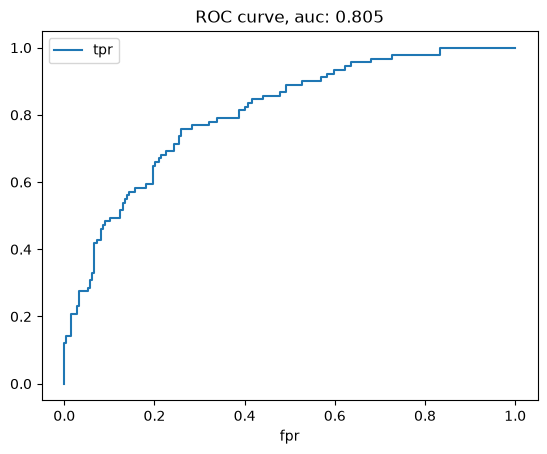

In [59]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_prob)
auc = metrics.auc(fpr, tpr)
auc

pd.DataFrame({'fpr': fpr, 'tpr': tpr}).plot(0, 1)
plt.title(f'ROC curve, auc: {auc:.3f}')

Text(0.5, 1.0, 'ROC curve, auc: 0.832')

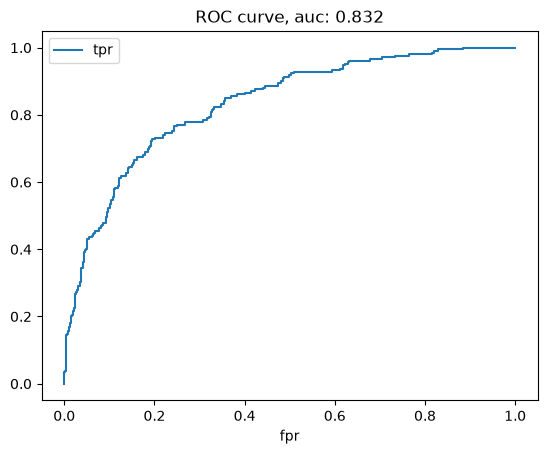

In [60]:
fpr, tpr, thresholds = metrics.roc_curve(y_train, y_train_prob)
auc = metrics.auc(fpr, tpr)
auc

pd.DataFrame({'fpr': fpr, 'tpr': tpr}).plot(0, 1)
plt.title(f'ROC curve, auc: {auc:.3f}')

Text(0, 0.5, 'f1 score')

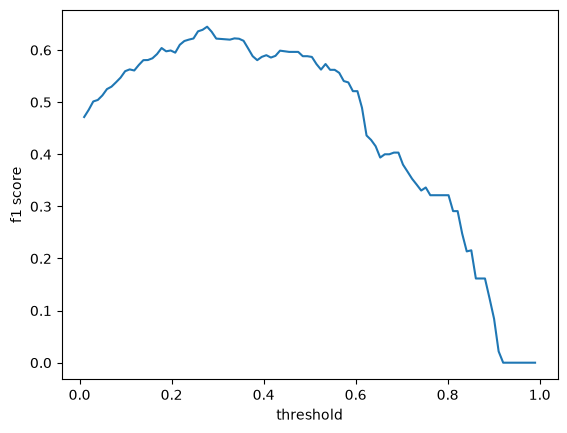

In [67]:
scores = {}
for t in np.linspace(0.01, 0.99, 100):
    y_test_prob = est.predict_proba(X_test)[:, 1]
    y_test_pred = np.where(y_test_prob >t, 1, 0)
    f1 = metrics.f1_score(y_test, y_test_pred)
    scores[t] = f1

pd.Series(scores).plot()
plt.xlabel('threshold')
plt.ylabel('f1 score')

In [70]:
y_train_prob = est.predict_proba(X_train)[:, 1]
y_test_prob = est.predict_proba(X_test)[:, 1]

y_train_pred = np.where(y_train_prob >0.3, 1, 0)
y_test_pred = np.where(y_test_prob >0.3, 1, 0)

print(metrics.confusion_matrix(y_test, y_test_pred))
print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("train precision: ", metrics.precision_score(y_train, y_train_pred))
print("train recall: ", metrics.recall_score(y_train, y_train_pred))
print("train f1: ", metrics.f1_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))
print("test precision: ", metrics.precision_score(y_test, y_test_pred))
print("test recall: ", metrics.recall_score(y_test, y_test_pred))
print("test f1: ", metrics.f1_score(y_test, y_test_pred))

[[156  53]
 [ 26  65]]
train accuracy:  0.7585714285714286
train precision:  0.572992700729927
train recall:  0.7511961722488039
train f1:  0.650103519668737
test accuracy:  0.7366666666666667
test precision:  0.5508474576271186
test recall:  0.7142857142857143
test f1:  0.6220095693779905


In [71]:
est

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [72]:
est.coef_

array([[ 0.40963406,  0.21155044,  0.38811922, -0.02406278, -0.11710475,
         0.25251068,  0.09035524,  0.22935204, -0.18556647, -0.62593626,
         0.11399681,  0.2702807 ,  0.4109633 ,  0.44119784,  0.215466  ,
        -0.22339762, -0.08952244,  0.10400449, -0.13964849, -0.10757721,
        -0.21276083, -0.00518868, -0.09011766,  0.03844269,  0.12182468,
        -0.23190988, -0.26192769,  0.00080652, -0.31955747, -0.19835454,
        -0.03526934, -0.01164205, -0.08253956, -0.24131369, -0.25225233,
        -0.12857911,  0.05488073,  0.01611544,  0.35084928, -0.21708954,
        -0.01850218,  0.2844326 ,  0.3462235 , -0.12363868,  0.1805749 ,
         0.17214048, -0.03359283,  0.04540543]])

(array([ 1.,  0.,  1.,  7.,  7., 10.,  7.,  5.,  4.,  6.]),
 array([-0.62593626, -0.51922285, -0.41250944, -0.30579603, -0.19908262,
        -0.09236921,  0.0143442 ,  0.12105761,  0.22777102,  0.33448443,
         0.44119784]),
 <BarContainer object of 10 artists>)

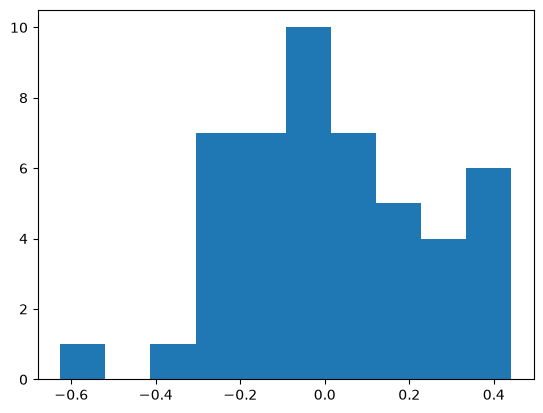

In [74]:
plt.hist(est.coef_[0])